# TP3: Fonctions descroptives

## 1. Segmentation des données suivant la longueur de séquence

On commmence par charger le jeu de données

In [1]:
import pandas as pd

data_arn = pd.read_csv('TP3-data.csv')

print(data_arn.head())



                           id  \
0      AAIY01303410.1/717-923   
1  CP000140.1/4143906-4143709   
2   URS0000D6BCE7_12908/1-215   
3          X71081.1/4425-4646   
4     AACY020770731.1/455-512   

                                            sequence  
0  CCAACGUGGAUACUCCCGGGAGGUCACUCUCCCCGGGCUCUGUCCA...  
1  UACCUUUGCAUCCGAAUUGGUUCCGUACGCUCGUUCGGGCAUACGG...  
2  GCGUAACGCGCUAUGGCUUAAACGGCUGCCCCAAAGCUGCCAAAGG...  
3  CCAAUGUGGAUAUCCUUAGAGGUCUCUCUUGGGCUCUGUCCAGGUG...  
4  UUUCGUUCACCCUCAAUUGAGGGCGCAGUUCGAGUCAUACCAUGGA...  


### a.Distribution des longueurs de séquences 

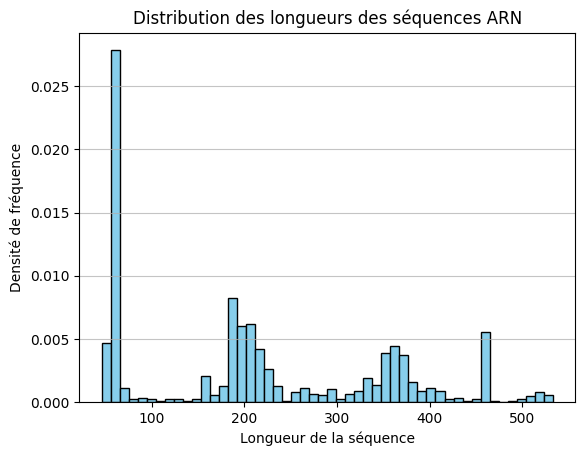

In [2]:
import matplotlib.pyplot as plt
import numpy as np

data_arn['sequence_lengh'] = data_arn['sequence'].str.len()

# Création de l'histogramme
plt.hist(data_arn['sequence_lengh'], bins=50, color='skyblue', edgecolor='black', density=True)
plt.title('Distribution des longueurs des séquences ARN')
plt.xlabel('Longueur de la séquence')
plt.ylabel('Densité de fréquence')
plt.grid(axis='y', alpha=0.75)

### b. Partitionnement des données

On observe une distribution très hétérogène des longueurs des séquences d'ARN. Pour la suite il est nécessaire de les partitionner en groupes de longueurs similaires, et ce pour plusieurs raisons:
- les différents pics correspondent à des familles d'ARN spécifiques. Ainsi, en partitionnant par longueur, 

In [3]:
# Nous allons partitionner les séquences d'ARN en 4 groupes distincts: très courtes, courtes, moyennes et longues

# groupe 1: pic principal autour de 70

g1 = data_arn[(data_arn['sequence_lengh'] >= 50) & (data_arn['sequence_lengh'] <= 100)]

# groupe 2: cluster autour de 200

g2 = data_arn[(data_arn['sequence_lengh'] >= 100) & (data_arn['sequence_lengh'] <= 250)]

# groupe 3 : cluster autour de 360

g3 = data_arn[(data_arn['sequence_lengh'] >= 250) & (data_arn['sequence_lengh'] <= 430)]

# groupe 4 : pic autour de 460

g4 = data_arn[data_arn['sequence_lengh'] > 430]

# 3. Affichage des statistiques pour vérification
print(f"Nombre de séquences par groupe :")
print(f" - G1 (Très courtes) : {len(g1)}")
print(f" - G2 (Courtes)      : {len(g2)}")
print(f" - G3 (Moyennes)     : {len(g3)}")
print(f" - G4 (Longues)      : {len(g4)}")

# 4. Sauvegarde physique des données pour les futurs modèles


Nombre de séquences par groupe :
 - G1 (Très courtes) : 301
 - G2 (Courtes)      : 293
 - G3 (Moyennes)     : 232
 - G4 (Longues)      : 73


## 2. Partitionnement à partir d’une représentation vectorielle des données

### a. représentation vectorielle des séquences basée sur les 2-mer, 3-mer et 4-mer

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

def generate_kmers_features(df, k):
    def split_kmers(sequence,k):
        return " ".join([sequence[i:i+k] for i in range(len(sequence) - k + 1)])
    
    kmers_text = df['sequence'].apply(lambda x: split_kmers(x, k))

    # Vectorisation

    vectorizer = CountVectorizer(analyzer='word')
    X = vectorizer.fit_transform(kmers_text)

    # normalisation par la longueur pour que les groupes de longueurs très différents soient comparables
    # en particulier g1 et g3

    X_normalized = X.toarray() / X.toarray().sum(axis=1)[:, None]
    
    return pd.DataFrame(X_normalized, columns=vectorizer.get_feature_names_out())

In [5]:
features_g1_3mer = generate_kmers_features(g1, k=3)
print(features_g1_3mer.head())

        aaa       aac       aag       aau       aca       acc       acg  \
0  0.000000  0.017857  0.000000  0.017857  0.000000  0.035714  0.017857   
1  0.000000  0.018868  0.000000  0.018868  0.000000  0.037736  0.018868   
2  0.169492  0.033898  0.016949  0.067797  0.000000  0.016949  0.000000   
3  0.016129  0.000000  0.016129  0.016129  0.032258  0.000000  0.000000   
4  0.103448  0.034483  0.034483  0.000000  0.000000  0.017241  0.017241   

        acu       aga       agc  ...       ucg       ucu       uga       ugc  \
0  0.000000  0.000000  0.000000  ...  0.035714  0.000000  0.017857  0.000000   
1  0.000000  0.000000  0.037736  ...  0.018868  0.000000  0.000000  0.000000   
2  0.016949  0.033898  0.016949  ...  0.033898  0.000000  0.033898  0.033898   
3  0.000000  0.016129  0.032258  ...  0.000000  0.000000  0.016129  0.032258   
4  0.000000  0.000000  0.034483  ...  0.017241  0.034483  0.017241  0.034483   

        ugg       ugu       uua       uuc       uug       uuu  
0  0

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

def generate_kmers(df, k_list=[2,3,4]):
    "cette fonction permet de générer un seul dataframe avec les k-mers de chaque groupe de longueurs"

    all_k_features = []

    for k in k_list:
        kmer_strings = df['sequence'].apply(lambda s: " ".join([s[i:i+k] for i in range(len(s)-k+1)]))

        vectorizer = CountVectorizer(analyzer='word')
        X = vectorizer.fit_transform(kmer_strings).toarray()

        # normalisation par la somme de la ligne
        X_norm = X /X.sum(axis=1, keepdims = True)

        # création du dataframe

        cols = [f"{k}mer_{name}" for name in vectorizer.get_feature_names_out()]
        all_k_features.append(pd.DataFrame(X_norm, columns=cols, index=df.index))

    # on concatène ensuite horizontalement tous les k-means

    return pd.concat(all_k_features, axis=1)
        

In [7]:
dict_features = {}
g_glob = [g1,g2,g3,g4]

for i, group_df in enumerate(g_glob):
    print(f"Traitement du Groupe G{i+1}...")
    dict_features[f"G{i+1}"] = generate_kmers(group_df)

Traitement du Groupe G1...
Traitement du Groupe G2...
Traitement du Groupe G3...
Traitement du Groupe G4...


In [8]:
print(dict_features["G1"].head())

    2mer_aa   2mer_ac   2mer_ag   2mer_au   2mer_ca   2mer_cc   2mer_cg  \
4  0.035088  0.052632  0.052632  0.070175  0.087719  0.052632  0.070175   
5  0.037037  0.055556  0.074074  0.092593  0.055556  0.074074  0.074074   
7  0.283333  0.033333  0.066667  0.083333  0.033333  0.016667  0.033333   
8  0.047619  0.031746  0.095238  0.015873  0.079365  0.126984  0.063492   
9  0.169492  0.033898  0.084746  0.067797  0.033898  0.016949  0.033898   

    2mer_cu   2mer_ga   2mer_gc  ...  4mer_uucg  4mer_uucu  4mer_uuga  \
4  0.017544  0.070175  0.052632  ...   0.036364        0.0   0.018182   
5  0.037037  0.055556  0.074074  ...   0.019231        0.0   0.000000   
7  0.050000  0.100000  0.050000  ...   0.000000        0.0   0.017241   
8  0.047619  0.047619  0.111111  ...   0.000000        0.0   0.016393   
9  0.084746  0.067797  0.067797  ...   0.000000        0.0   0.000000   

   4mer_uugc  4mer_uugg  4mer_uugu  4mer_uuua  4mer_uuuc  4mer_uuug  4mer_uuuu  
4   0.000000        0.0   0.0

On peut voir ici la matrice des séquences des k-mers. Les valeurs numériques représentent les fréquences relatives locales des séquences.

### b. Extraction des motifs fréquents

Nos datasets sont composés par les fréquences relatives locales des séquences. Nous avons alors besoin de transformer nos datasets de la manière suivante: on transforme nos nombres en valeurs binaires, puis on fait la moyenne par colonne.

In [9]:
def find_frenquent_motifs(dict_features):

    dict_features_filtered = {}
    for group_name, df in dict_features.items():
        # on créé une matrice booléenne et on calcule la moyenne par colonne

        presence_proportion = (df >0).mean()

        frequent_cols = presence_proportion[presence_proportion >= 1/3].index

        # on trie par importance décroissante 

        dict_features_filtered[group_name] = df[frequent_cols]

        print(f"{group_name} : {len(frequent_cols)} motifs conservés sur {df.shape[1]}")

    return dict_features_filtered


In [10]:
dict_features_filtered = find_frenquent_motifs(dict_features)

# Affichage des 10 motifs les plus fréquents pour le groupe G1
print("Top 10 motifs fréquents dans G1 :")
print(dict_features_filtered["G1"].head(10))

G1 : 109 motifs conservés sur 336
G2 : 318 motifs conservés sur 366
G3 : 335 motifs conservés sur 368
G4 : 325 motifs conservés sur 336
Top 10 motifs fréquents dans G1 :
     2mer_aa   2mer_ac   2mer_ag   2mer_au   2mer_ca   2mer_cc   2mer_cg  \
4   0.035088  0.052632  0.052632  0.070175  0.087719  0.052632  0.070175   
5   0.037037  0.055556  0.074074  0.092593  0.055556  0.074074  0.074074   
7   0.283333  0.033333  0.066667  0.083333  0.033333  0.016667  0.033333   
8   0.047619  0.031746  0.095238  0.015873  0.079365  0.126984  0.063492   
9   0.169492  0.033898  0.084746  0.067797  0.033898  0.016949  0.033898   
16  0.118644  0.067797  0.050847  0.118644  0.118644  0.016949  0.067797   
18  0.000000  0.078431  0.019608  0.019608  0.039216  0.156863  0.156863   
21  0.071429  0.053571  0.035714  0.089286  0.071429  0.053571  0.053571   
22  0.169492  0.067797  0.084746  0.084746  0.084746  0.033898  0.016949   
24  0.098361  0.032787  0.081967  0.065574  0.065574  0.081967  0.0819

Il est important de retirer les motifs les moins fréquents pour lutter contre la malédiction de la dimensionnalité. En effet, plus on a de colonnes par rapport au nombre de lignes, plus les distances entre les points deviennent uniformes. Le filtrage rend les algorithmes de clustering(comme K-Means) beaucoup plus performants. D'autre part, il est plus simple d'analyser un modèle basé sur quelques motifs récurrents plutôt que sur beaucoup de motifs rares.

### c. Nombre de clusters idéal 

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def find_best_k(df, max_k=10):
    silhouettes = []
    k_range = list(range(2, max_k + 1)) # Conversion en liste pour éviter les erreurs d'index
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        cluster_labels = kmeans.fit_predict(df)

        # Calcul du silhouette score
        score = silhouette_score(df, cluster_labels)
        silhouettes.append(score)

    
    best_k = k_range[np.argmax(silhouettes)]
    
    # Alerte si le meilleur k est le maximum autorisé
    if best_k == max_k:
        print(f"⚠️ Attention : Le meilleur k est {max_k}. Il faudrait peut-être tester des valeurs plus hautes.")
        
    return k_range, silhouettes, best_k

Meilleur k pour G1 : 6 (Silhouette: 0.273)


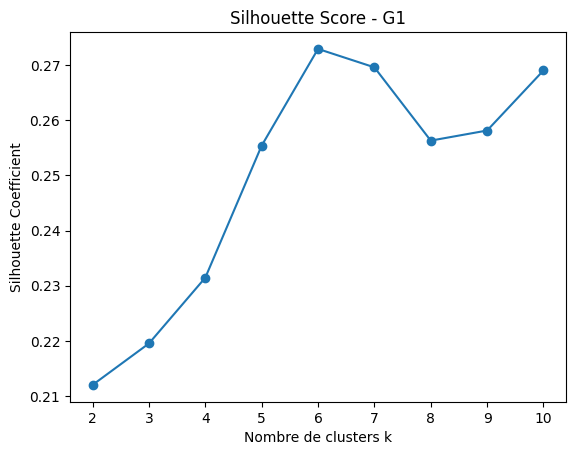

Meilleur k pour G2 : 2 (Silhouette: 0.180)


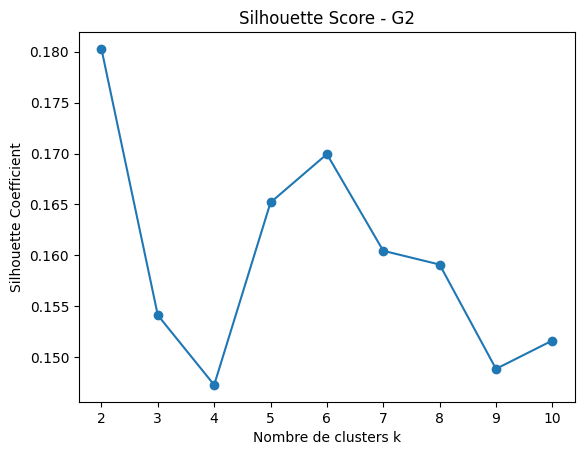

Meilleur k pour G3 : 2 (Silhouette: 0.230)


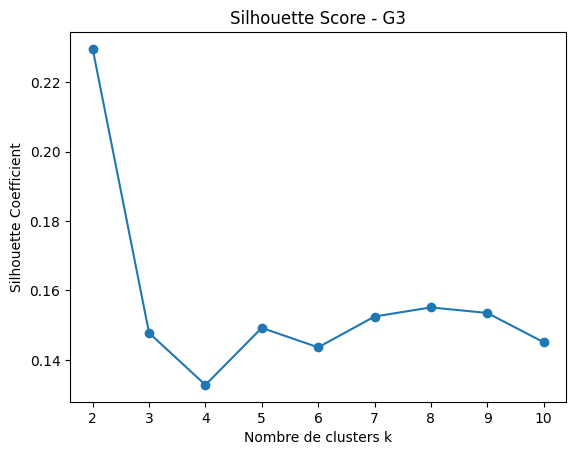

Meilleur k pour G4 : 4 (Silhouette: 0.535)


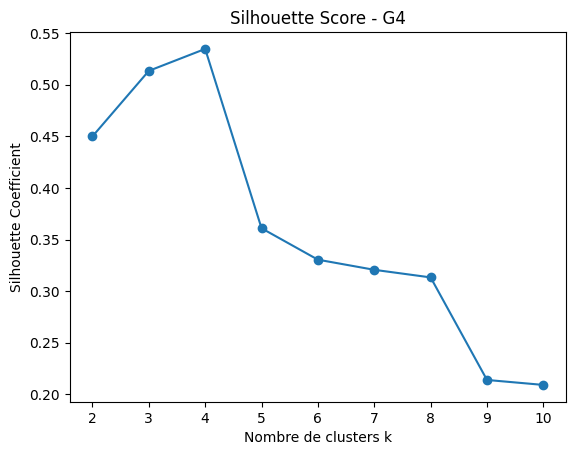

In [12]:
for group_name, df_filtered in dict_features_filtered.items():
    k_range, silhouettes, best_k = find_best_k(df_filtered)
    print(f"Meilleur k pour {group_name} : {best_k} (Silhouette: {max(silhouettes):.3f})")

    plt.plot(k_range, silhouettes, marker='o')
    plt.title(f"Silhouette Score - {group_name}")
    plt.xlabel("Nombre de clusters k")
    plt.ylabel("Silhouette Coefficient")
    plt.show()

## 3. Partitionnement à partir d'une matrice de distances

### a. Matrice des distances d'édition

In [13]:
from Bio import pairwise2
import numpy as np
# génération de la matrice des distances d'édition

def compute_edition_distance_matrix(group_df):
    sequences = group_df['sequence'].tolist()
    n = len(sequences)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            # Calcul de la distance d'édition entre les séquences i et j
            
            s1, s2 = sequences[i], sequences[j]

            alignments = pairwise2.align.globalxx(s1, s2)

            distance = min([al[4] - al[2] for al in alignments])

            # La matrice est symétrique
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    return distance_matrix


c:\Users\maell\AppData\Local\Programs\Python\Python310\lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [17]:
distance_matrix = {}
dist_matrices = {}
for i, group_df in enumerate(g_glob):
    print(f"Calcul de la matrice de distance pour le Groupe G{i+1}...")
    group_name = f"G{i+1}"
    dist_matrices[group_name] = compute_edition_distance_matrix(group_df)
    print(f"Matrice de distance pour {group_name} calculée.")

print(f"Distance matrix for G1:\n{dist_matrices['G1']}")
print(f"Distance matrix for G2:\n{dist_matrices['G2']}")
print(f"Distance matrix for G3:\n{dist_matrices['G3']}")
print(f"Distance matrix for G4:\n{dist_matrices['G4']}")

Calcul de la matrice de distance pour le Groupe G1...
Matrice de distance pour G1 calculée.
Calcul de la matrice de distance pour le Groupe G2...
Matrice de distance pour G2 calculée.
Calcul de la matrice de distance pour le Groupe G3...
Matrice de distance pour G3 calculée.
Calcul de la matrice de distance pour le Groupe G4...
Matrice de distance pour G4 calculée.
Distance matrix for G1:
[[ 0.  8. 56. ... 53.  1. 48.]
 [ 8.  0. 55. ... 53. 10. 43.]
 [56. 55.  0. ... 14. 57. 41.]
 ...
 [53. 53. 14. ...  0. 53. 43.]
 [ 1. 10. 57. ... 53.  0. 47.]
 [48. 43. 41. ... 43. 47.  0.]]
Distance matrix for G2:
[[  0. 144. 153. ... 153. 155. 144.]
 [144.   0. 158. ... 132. 137. 133.]
 [153. 158.   0. ... 132. 146. 148.]
 ...
 [153. 132. 132. ...   0. 127. 145.]
 [155. 137. 146. ... 127.   0. 140.]
 [144. 133. 148. ... 145. 140.   0.]]
Distance matrix for G3:
[[  0. 246. 277. ... 266. 241. 251.]
 [246.   0. 205. ... 248. 248. 172.]
 [277. 205.   0. ... 276. 263. 189.]
 ...
 [266. 248. 276. ...   0

### B. algorithme des Kmedoids 

In [21]:
# fonction de clustering kmédoids à a partir de la matrice de distance d'édition
#implementation de la fonction Kmedoids(n_clusters, X)

def k_medoids(n_clusters, X):  
    # n_clusters: nombre de clusters
    # X: matrice de distance d'édition
    # retourne les indices des medoids et les labels des clusters
    # initialisation aléatoire des medoids
    m, n = X.shape
    medoids = np.random.choice(m, n_clusters, replace=False)

    while True:
        # assignation des points aux medoids les plus proches
        distances = X[:, medoids]
        labels = np.argmin(distances, axis=1)

        # mise à jour des medoids
        new_medoids = np.copy(medoids)
        for i in range(n_clusters):
            cluster_points = np.where(labels == i)[0]
            if len(cluster_points) > 0:
                cluster_distances = X[np.ix_(cluster_points, cluster_points)]
                total_distances = np.sum(cluster_distances, axis=1)
                new_medoids[i] = cluster_points[np.argmin(total_distances)]

        # vérification de la convergence
        if np.array_equal(medoids, new_medoids):
            break
        medoids = new_medoids

    return medoids, labels


In [24]:
def find_best_k_from_distance_matrix(dist_matrix, max_k=10):
    # dist_matrix: matrice de distance d'édition
    # max_k: nombre maximum de clusters à tester
    # retourne le meilleur nombre de clusters selon la silhouette score
    best_k = 2
    best_score = -1
    scores = []
    for k in range(2, max_k + 1):
        medoids, labels = k_medoids(k, dist_matrix)
        score = silhouette_score(dist_matrix, labels, metric='precomputed')
        scores.append(score)
        if score > best_score:
            best_score = score
            best_k = k
        #graphique de la silouette score en fonction de k
    plt.plot(range(2, max_k + 1), scores, marker='o')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score en fonction de k')
    plt.xticks(range(2, max_k + 1))
    plt.grid()
    plt.show()
    
    return best_k

Recherche du meilleur nombre de clusters pour G1...


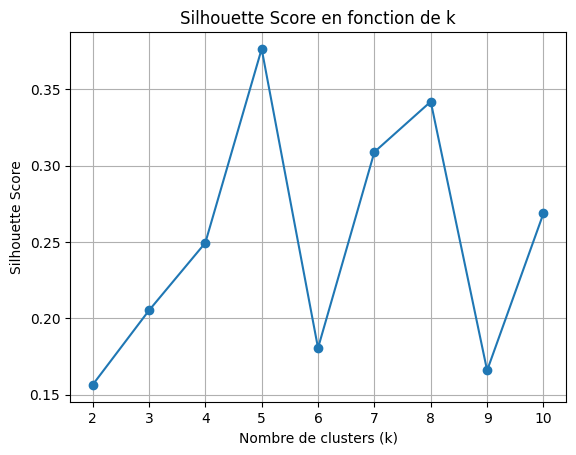

Meilleur k pour G1 : 5
Recherche du meilleur nombre de clusters pour G2...


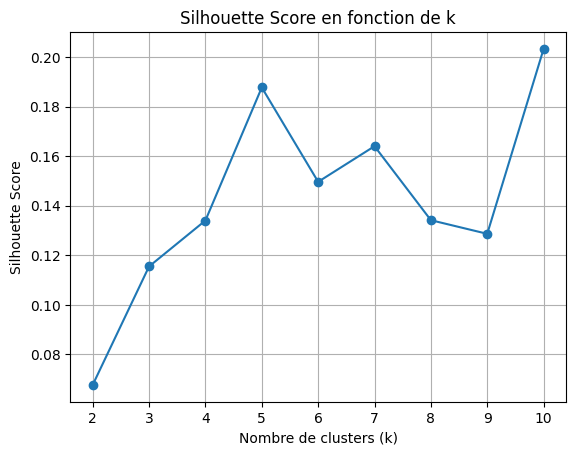

Meilleur k pour G2 : 10
Recherche du meilleur nombre de clusters pour G3...


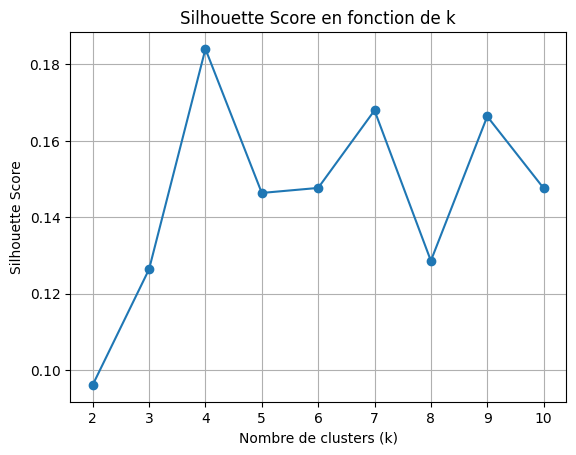

Meilleur k pour G3 : 4
Recherche du meilleur nombre de clusters pour G4...


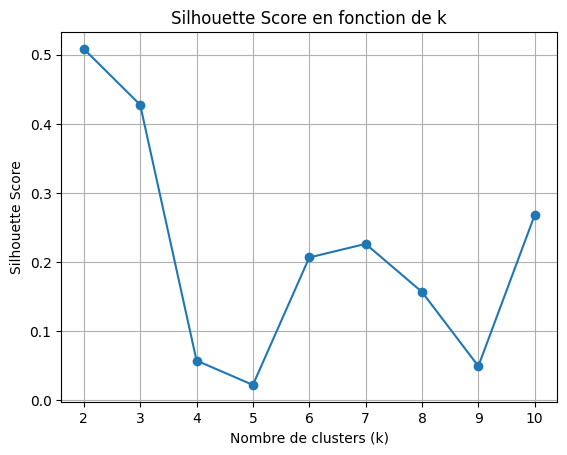

Meilleur k pour G4 : 2


In [25]:
#cherchons le meilleur nombre de cluster selon les k-medoids sur la matrice de distance d'édition
for group_name, dist_matrix in dist_matrices.items():
    print(f"Recherche du meilleur nombre de clusters pour {group_name}...")
    best_k = find_best_k_from_distance_matrix(dist_matrix)
    print(f"Meilleur k pour {group_name} : {best_k}")